In [3]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

plt.style.use("ggplot")

In [4]:
import os

print("RAW FILES:")
print(os.listdir("data/raw"))

print("\nPROCESSED FILES:")
print(os.listdir("data/processed"))

RAW FILES:
['hdfc_top100_nav.csv']

PROCESSED FILES:
['hdfc_top100_nav_clean.csv']


In [5]:
df = pd.read_csv("data/processed/hdfc_top100_nav_clean.csv")

df.head()

,date,nav
0,2013-11-18,13.0894
1,2013-11-19,13.1068
2,2013-11-20,12.9549
3,2013-11-21,12.7957
4,2013-11-22,12.7775


In [6]:
df.columns

Index(['date', 'nav'], dtype='str')

In [7]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 3091 entries, 0 to 3090
Data columns (total 2 columns):
 #   Column  Non-Null Count  Dtype  
---  ------  --------------  -----  
 0   date    3091 non-null   str    
 1   nav     3091 non-null   float64
dtypes: float64(1), str(1)
memory usage: 48.4 KB


In [8]:
df["date"] = pd.to_datetime(df["date"])
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 3091 entries, 0 to 3090
Data columns (total 2 columns):
 #   Column  Non-Null Count  Dtype         
---  ------  --------------  -----         
 0   date    3091 non-null   datetime64[us]
 1   nav     3091 non-null   float64       
dtypes: datetime64[us](1), float64(1)
memory usage: 48.4 KB


In [9]:
df.describe()

,date,nav
count,3091,3091.000000
mean,2020-02-29 10:02:22.089938,89.939213
min,2013-11-18 00:00:00,12.777500
25%,2017-01-11 12:00:00,40.158600
50%,2020-03-04 00:00:00,61.164900
75%,2023-04-20 12:00:00,130.278600
max,2026-06-01 00:00:00,214.676700
std,NaN,60.338745


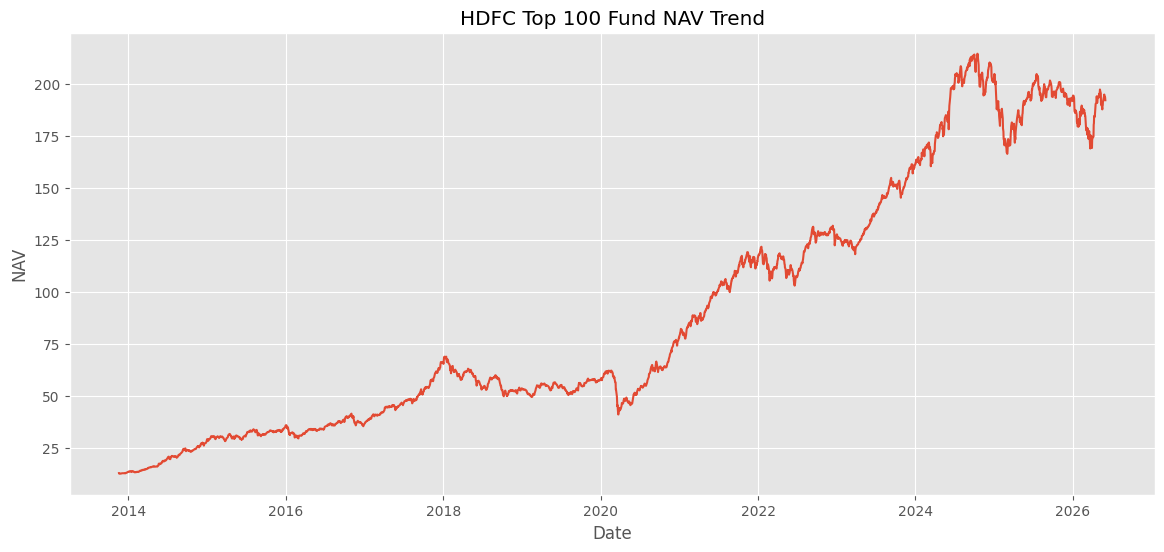

In [10]:
plt.figure(figsize=(14,6))

plt.plot(df["date"], df["nav"])

plt.title("HDFC Top 100 Fund NAV Trend")
plt.xlabel("Date")
plt.ylabel("NAV")

plt.show()

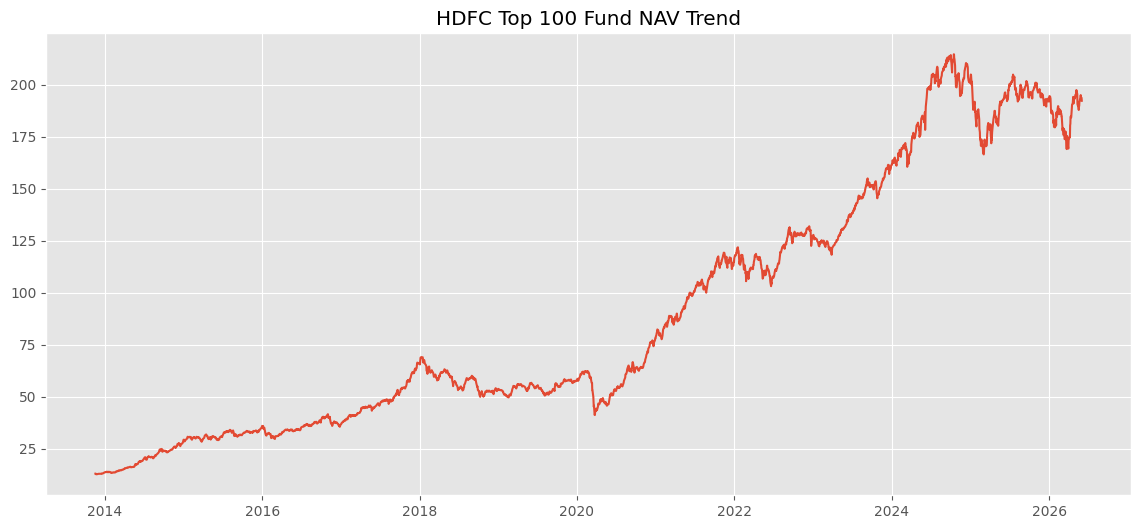

In [11]:
plt.figure(figsize=(14,6))

plt.plot(df["date"], df["nav"])

plt.title("HDFC Top 100 Fund NAV Trend")

plt.savefig("reports/nav_trend.png")

plt.show()

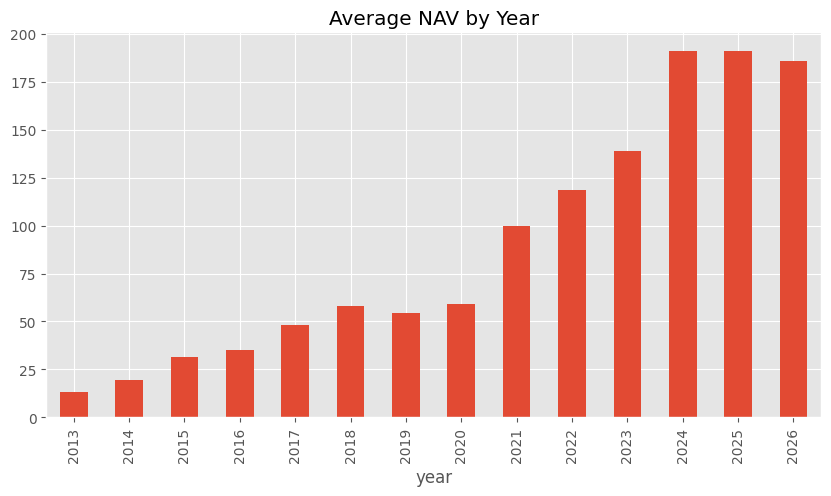

In [12]:
df["year"] = df["date"].dt.year

year_nav = df.groupby("year")["nav"].mean()

year_nav.plot(
    kind="bar",
    figsize=(10,5)
)

plt.title("Average NAV by Year")

plt.show()

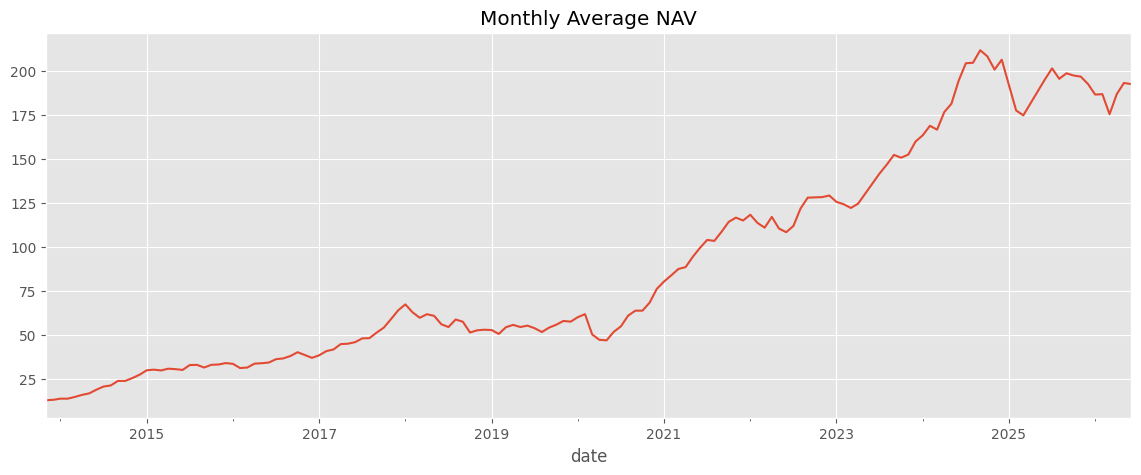

In [14]:
monthly_nav = (
    df.set_index("date")
      .resample("ME")["nav"]
      .mean()
)

monthly_nav.plot(
    figsize=(14,5)
)

plt.title("Monthly Average NAV")

plt.show()

In [15]:
df["daily_return"] = df["nav"].pct_change() * 100

df.head()

,date,nav,year,daily_return
0,2013-11-18,13.0894,2013,NaN
1,2013-11-19,13.1068,2013,0.132932
2,2013-11-20,12.9549,2013,-1.158940
3,2013-11-21,12.7957,2013,-1.228879
4,2013-11-22,12.7775,2013,-0.142235


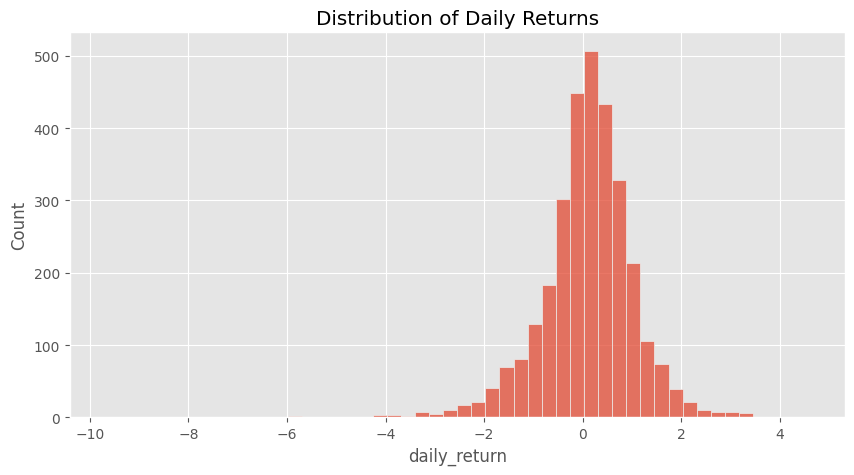

In [16]:
plt.figure(figsize=(10,5))

sns.histplot(
    df["daily_return"].dropna(),
    bins=50
)

plt.title("Distribution of Daily Returns")

plt.show()

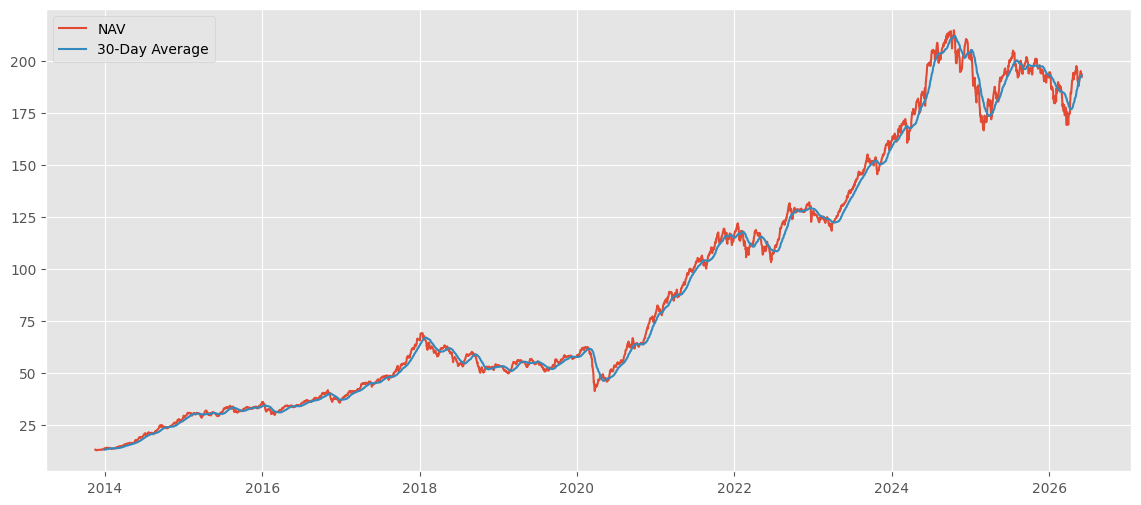

In [17]:
df["rolling_30"] = (
    df["nav"]
      .rolling(30)
      .mean()
)

plt.figure(figsize=(14,6))

plt.plot(df["date"], df["nav"], label="NAV")

plt.plot(
    df["date"],
    df["rolling_30"],
    label="30-Day Average"
)

plt.legend()

plt.show()

In [18]:
print("Highest NAV")
print(df.loc[df["nav"].idxmax()])

print()

print("Lowest NAV")
print(df.loc[df["nav"].idxmin()])

Highest NAV
date            2024-10-15 00:00:00
nav                        214.6767
year                           2024
daily_return               0.926443
rolling_30                211.57705
Name: 2685, dtype: object

Lowest NAV
date            2013-11-22 00:00:00
nav                         12.7775
year                           2013
daily_return              -0.142235
rolling_30                      NaN
Name: 4, dtype: object


In [19]:
import os

for root, dirs, files in os.walk("data"):
    for file in files:
        print(os.path.join(root, file))

data\processed\hdfc_top100_nav_clean.csv
data\raw\hdfc_top100_nav.csv


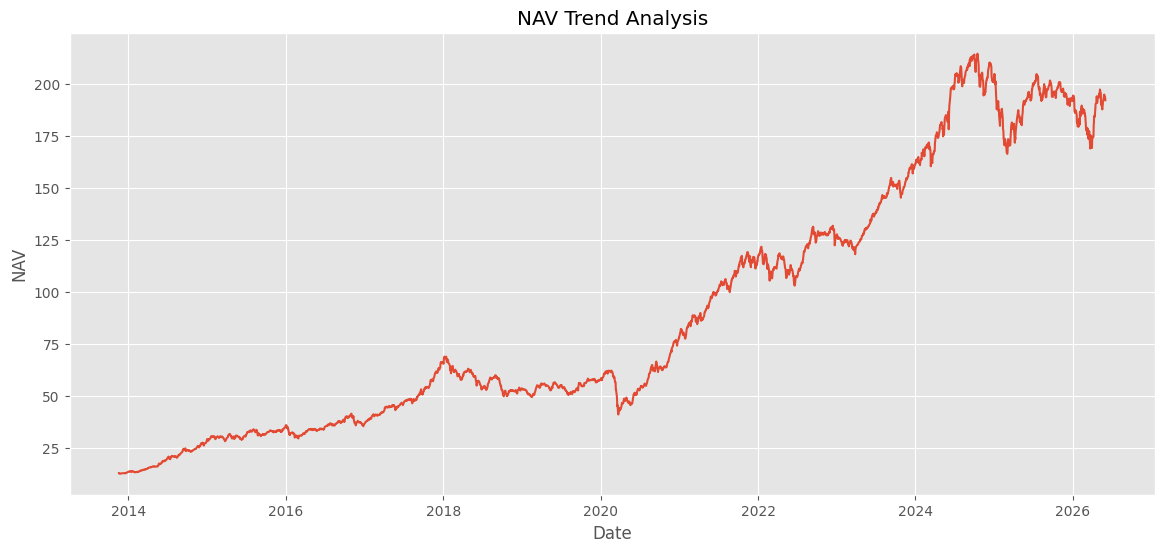

In [20]:
plt.figure(figsize=(14,6))
plt.plot(df["date"], df["nav"])

plt.title("NAV Trend Analysis")
plt.xlabel("Date")
plt.ylabel("NAV")

plt.savefig("reports/nav_trend.png")
plt.show()

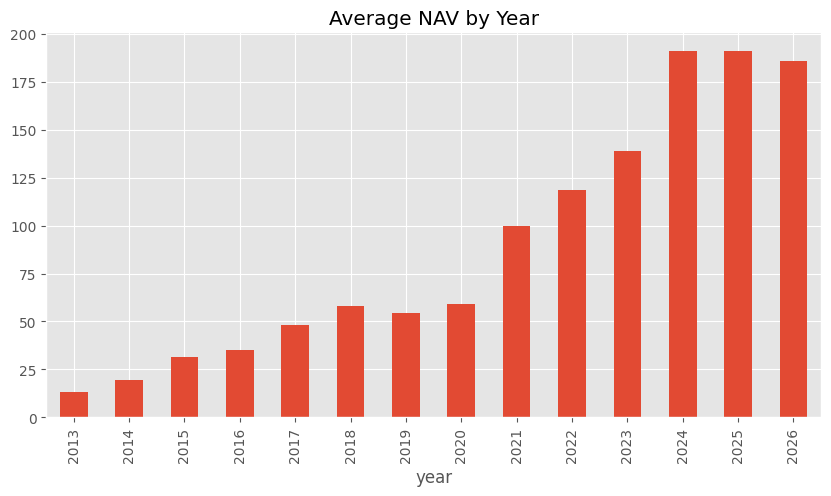

In [21]:
year_nav.plot(kind="bar", figsize=(10,5))

plt.title("Average NAV by Year")

plt.savefig("reports/yearly_nav.png")

plt.show()

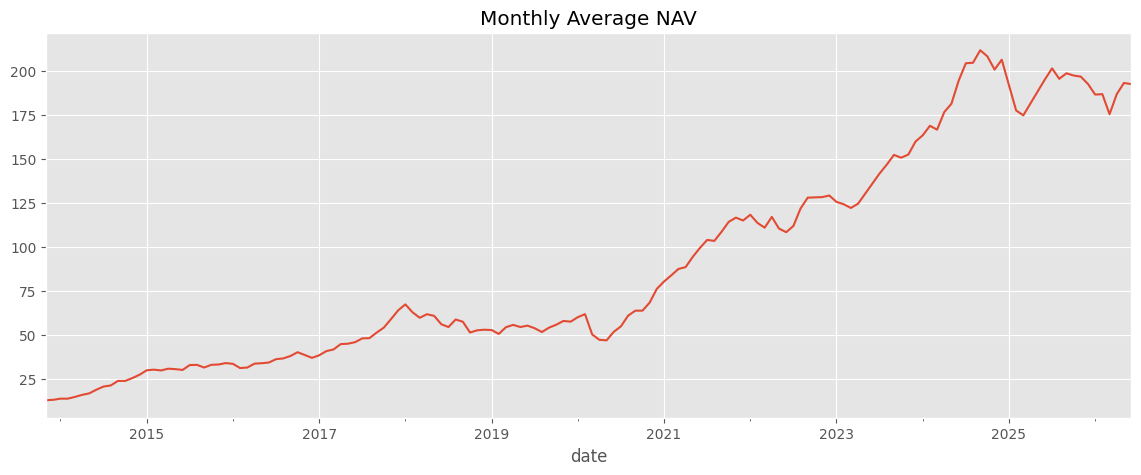

In [22]:
monthly_nav.plot(figsize=(14,5))

plt.title("Monthly Average NAV")

plt.savefig("reports/monthly_nav.png")

plt.show()

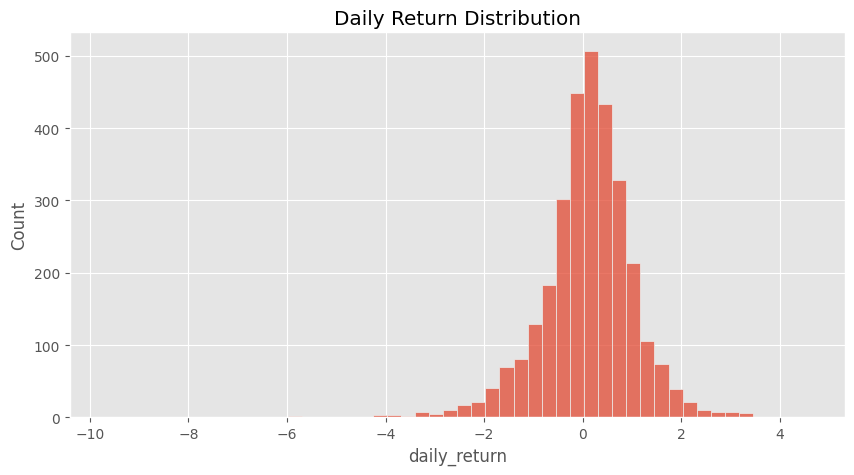

In [23]:
plt.figure(figsize=(10,5))

sns.histplot(df["daily_return"].dropna(), bins=50)

plt.title("Daily Return Distribution")

plt.savefig("reports/return_distribution.png")

plt.show()

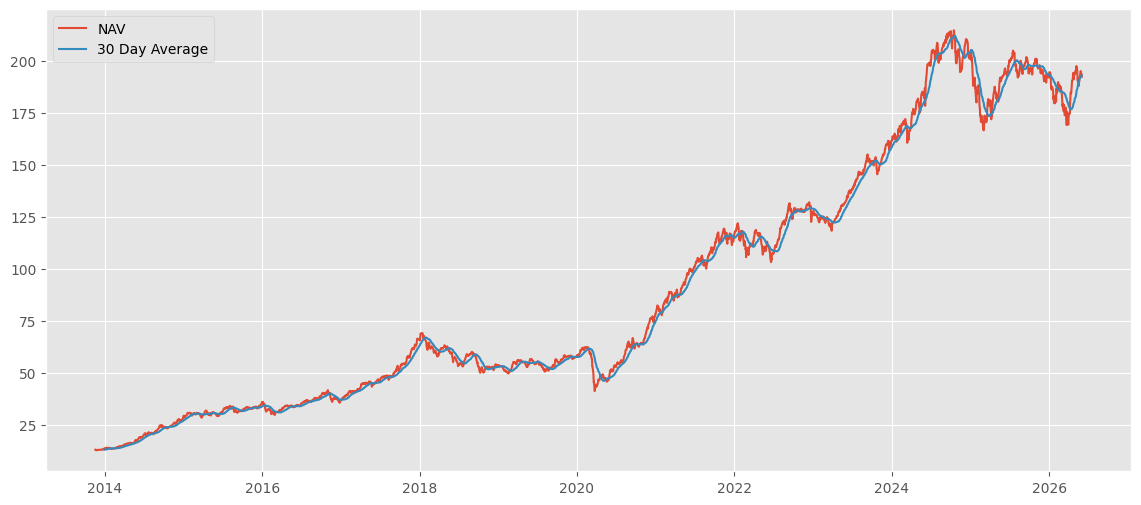

In [24]:
plt.figure(figsize=(14,6))

plt.plot(df["date"], df["nav"], label="NAV")
plt.plot(df["date"], df["rolling_30"], label="30 Day Average")

plt.legend()

plt.savefig("reports/rolling_average.png")

plt.show()

In [26]:
## EDA Findings

### Finding 1
NAV increased from ₹12.78 in 2013 to above ₹214 in 2024.

### Finding 2
Highest NAV recorded on 15-Oct-2024.

### Finding 3
Lowest NAV recorded on 22-Nov-2013.

### Finding 4
Long-term trend shows strong appreciation.

### Finding 5
Daily returns are centered around zero with occasional volatility.

### Finding 6
30-day moving average smooths short-term fluctuations.

### Finding 7
Monthly NAV trend shows sustained growth.

### Finding 8
Yearly average NAV consistently increased.

### Finding 9
Fund experienced temporary corrections but maintained long-term growth.

### Finding 10
Historical performance indicates strong compounding over time.


SyntaxError: invalid character '₹' (U+20B9) (698561097.py, line 4)

In [27]:
# Test
This is a markdown cell.

SyntaxError: invalid syntax (3991175278.py, line 2)

In [28]:
print("EDA Findings")
print("1. NAV increased significantly over the years.")
print("2. Highest NAV was recorded during the latest period.")
print("3. Lowest NAV was recorded during the initial period.")
print("4. Long-term trend shows strong growth.")
print("5. Daily returns show moderate volatility.")
print("6. 30-day moving average smooths short-term fluctuations.")
print("7. Monthly NAV trend indicates consistent growth.")
print("8. Yearly average NAV increased over time.")
print("9. Temporary market corrections were observed.")
print("10. Historical NAV performance shows strong compounding.")

EDA Findings
1. NAV increased significantly over the years.
2. Highest NAV was recorded during the latest period.
3. Lowest NAV was recorded during the initial period.
4. Long-term trend shows strong growth.
5. Daily returns show moderate volatility.
6. 30-day moving average smooths short-term fluctuations.
7. Monthly NAV trend indicates consistent growth.
8. Yearly average NAV increased over time.
9. Temporary market corrections were observed.
10. Historical NAV performance shows strong compounding.
